Using device: cpu
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


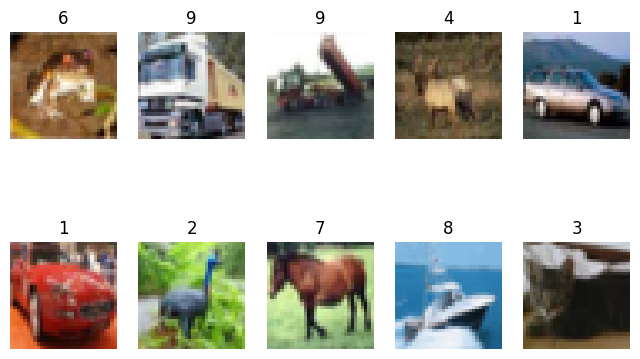

Extracting HOG features...

=== Baseline Accuracy ===

Training Logistic Regression...
Logistic Regression: 0.5120

Training SVM...
SVM: 0.5630

Training Random Forest...
Random Forest: 0.4575

=== Attack Visualizations ===


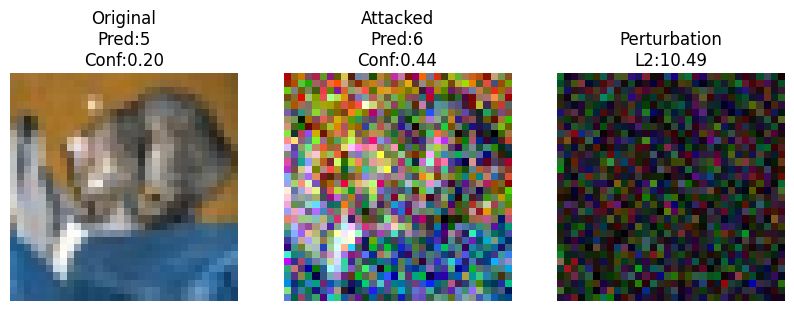

Confidence Drop: -0.24


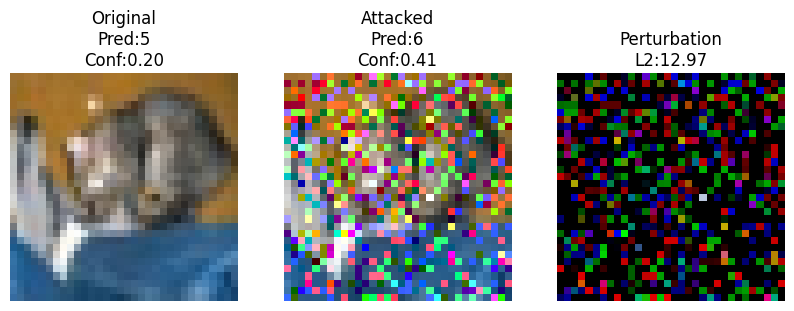

Confidence Drop: -0.20999999999999996


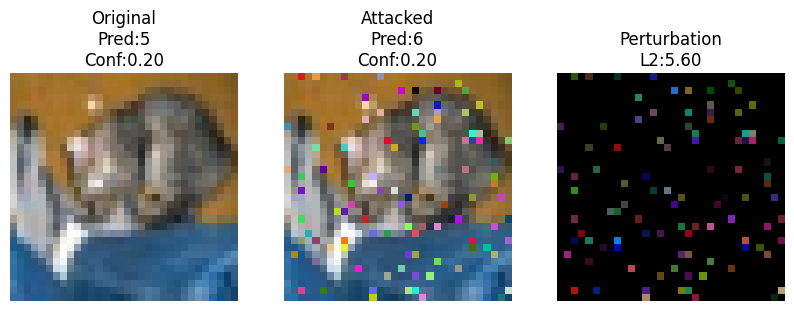

Confidence Drop: 0.0


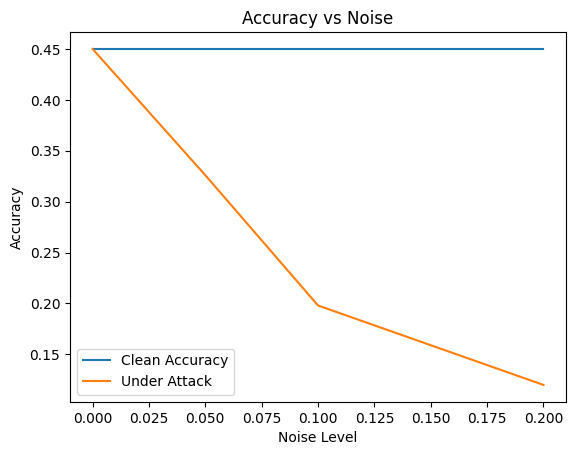


Training MLP...
Epoch 0: Loss = 2.3025
Epoch 1: Loss = 2.2935
Epoch 2: Loss = 2.2852
Epoch 3: Loss = 2.2771
Epoch 4: Loss = 2.2689

=== More Examples ===


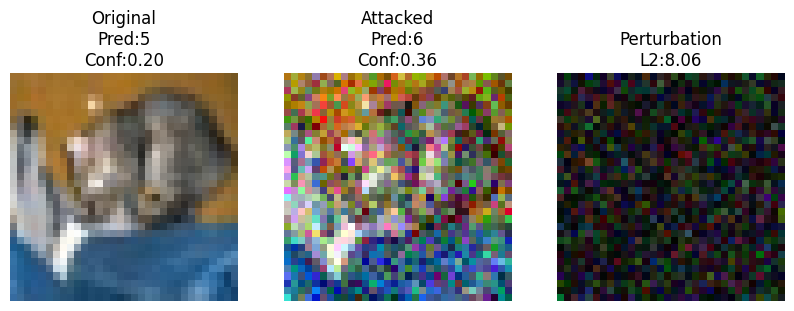

Confidence Drop: -0.15999999999999998


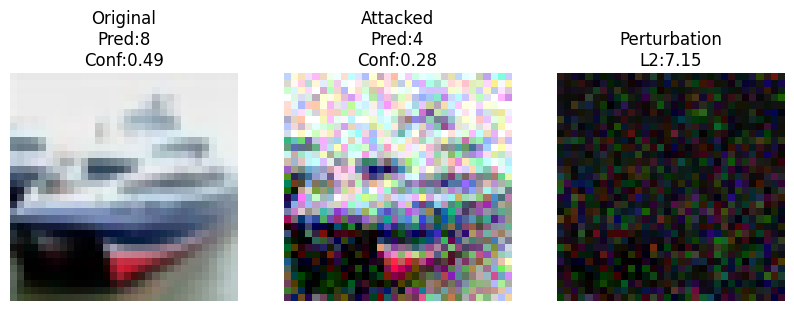

Confidence Drop: 0.20999999999999996


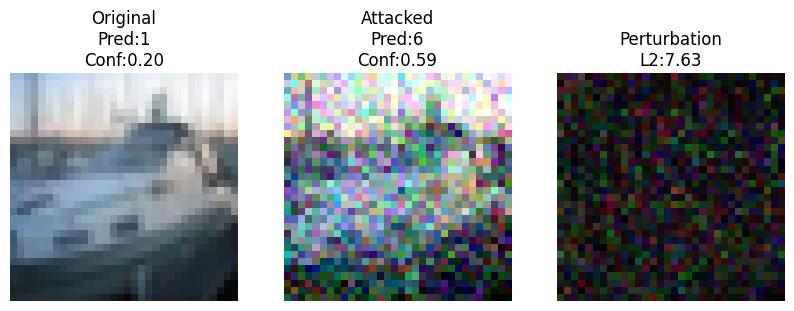

Confidence Drop: -0.38999999999999996


In [ ]:
# 🚗 Adversarial Attacks & Defense (ML Models – NO CNN)
# Complete End-to-End Colab Script
# Dataset: CIFAR-10 | Features: HOG
# Models: Logistic Regression, SVM, Random Forest


# 1. Environment Setup

!pip install numpy pandas matplotlib scikit-learn opencv-python scikit-image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')

# Optional GPU check
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)



# 2. Load Dataset (CIFAR-10)

from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape, "Test:", X_test.shape)

# Show sample images
plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis('off')
plt.show()


# 3. Feature Extraction (HOG)

def extract_hog(images):
    features = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype('uint8'), cv2.COLOR_RGB2GRAY)
        feat = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2))
        features.append(feat)
    return np.array(features)

# Reduce size for speed
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

print("Extracting HOG features...")
X_train_hog = extract_hog(X_train_small)
X_test_hog = extract_hog(X_test_small)


# 4. Train ML Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

print("\n=== Baseline Accuracy ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_hog, y_train_small)

    preds = model.predict(X_test_hog)
    acc = accuracy_score(y_test_small, preds)

    print(f"{name}: {acc:.4f}")



# 5. Adversarial Attacks

def gaussian_noise(img, std=0.1):
    noise = np.random.normal(0, std, img.shape)
    return np.clip(img + noise, 0, 1)

def salt_pepper(img, prob=0.05):
    noisy = img.copy()
    rnd = np.random.rand(*img.shape)
    noisy[rnd < prob] = 0
    noisy[rnd > 1 - prob] = 1
    return noisy

def pixel_attack(img, num_pixels=50):
    attacked = img.copy()
    h, w, c = img.shape
    for _ in range(num_pixels):
        x = np.random.randint(0, h)
        y = np.random.randint(0, w)
        attacked[x,y] = np.random.rand(3)
    return attacked



# 6. Visualization + Metrics

def analyze_attack(model, img, attack_fn, **kwargs):
    attacked = attack_fn(img, **kwargs)

    orig_feat = extract_hog([img])[0].reshape(1,-1)
    atk_feat = extract_hog([attacked])[0].reshape(1,-1)

    pred_before = model.predict(orig_feat)[0]
    pred_after = model.predict(atk_feat)[0]

    prob_before = model.predict_proba(orig_feat).max()
    prob_after = model.predict_proba(atk_feat).max()

    diff = attacked - img
    l2 = np.linalg.norm(diff)

    # Plot
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(f"Original\nPred:{pred_before}\nConf:{prob_before:.2f}")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(attacked)
    plt.title(f"Attacked\nPred:{pred_after}\nConf:{prob_after:.2f}")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(np.abs(diff))
    plt.title(f"Perturbation\nL2:{l2:.2f}")
    plt.axis('off')

    plt.show()

    print("Confidence Drop:", prob_before - prob_after)


# Example visualization
rf_model = models["Random Forest"]

print("\n=== Attack Visualizations ===")
sample_img = X_test_small[0]

analyze_attack(rf_model, sample_img, gaussian_noise, std=0.2)
analyze_attack(rf_model, sample_img, salt_pepper, prob=0.1)
analyze_attack(rf_model, sample_img, pixel_attack, num_pixels=100)



# 7. Defense Mechanisms

def gaussian_blur(img):
    return cv2.GaussianBlur(img, (5,5), 0)

def median_filter(img):
    return cv2.medianBlur((img*255).astype('uint8'), 5)/255.0

def detect_anomaly(prob_before, prob_after, threshold=0.2):
    return (prob_before - prob_after) > threshold



# 8. Evaluation (Accuracy vs Noise)

noise_levels = [0.0, 0.05, 0.1, 0.2]

clean_acc = []
attack_acc = []

model = rf_model

for nl in noise_levels:
    attacked_imgs = np.array([gaussian_noise(img, nl) for img in X_test_small[:500]])

    clean_feat = extract_hog(X_test_small[:500])
    atk_feat = extract_hog(attacked_imgs)

    acc1 = accuracy_score(y_test_small[:500], model.predict(clean_feat))
    acc2 = accuracy_score(y_test_small[:500], model.predict(atk_feat))

    clean_acc.append(acc1)
    attack_acc.append(acc2)

# Plot
plt.figure()
plt.plot(noise_levels, clean_acc, label="Clean Accuracy")
plt.plot(noise_levels, attack_acc, label="Under Attack")
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Noise")
plt.legend()
plt.show()



# 9. Optional: MLP (FGSM Setup)

import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(x)

X_train_t = torch.tensor(X_train_hog[:5000]).float()
y_train_t = torch.tensor(y_train_small[:5000]).long()

mlp = MLP(X_train_t.shape[1]).to(device)
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

print("\nTraining MLP...")
for epoch in range(5):
    optimizer.zero_grad()
    out = mlp(X_train_t.to(device))
    loss = loss_fn(out, y_train_t.to(device))
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")



# 10. Additional Visual Examples

print("\n=== More Examples ===")
for i in range(3):
    analyze_attack(rf_model, X_test_small[i], gaussian_noise, std=0.15)